<a href="https://colab.research.google.com/github/Codevalb/trabajo_final_programacion_II/blob/main/E8FP%20GRUPOejem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Clasificación de Enfermedades Cardíacas
**Fundamentos de la Programación II **

**Participantes del grupo:**
- Álvaro Falcó
- Elena Fernandez
- Valery Bedoya

---

## Objetivo
Predecir si un paciente tiene enfermedad cardíaca a partir de datos clínicos, utilizando el dataset de Cleveland Clinic y validando con datos de otros tres hospitales.


---
# SECCIÓN 1: Carga de datos y Análisis Exploratorio (EDA)
### Responsable: Álvaro Falcó

In [ ]:

#Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [6]:
#Carga de datos

#Se importa pandas, una librería utilizada para trabajar con datos en formato de tabla.
import pandas as pd

#Los 4 datasets no tienen cabecera.
#Por eso se crea una lista con los nombres de las columnas según la descripción del enunciado.
COLUMNS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalach', 'exang', 'oldpeak',
           'slope', 'ca', 'thal', 'num']

#Se carga el dataset de Cleveland.
#header=None indica que el archivo no tiene nombres de columnas.
#names=COLUMNS asigna los nombres definidos anteriormente.
#na_values='?' convierte los valores '?' en NaN.
df_cleveland   = pd.read_csv('cleveland.data.csv',   header=None, names=COLUMNS, na_values='?')

#Se carga el dataset de Hungría usando la misma estructura de columnas.
df_hungarian   = pd.read_csv('hungarian.data.csv',   header=None, names=COLUMNS, na_values='?')

#Se carga el dataset de VA usando la misma estructura de columnas.
df_va          = pd.read_csv('va.data.csv',          header=None, names=COLUMNS, na_values='?')

#Se carga el dataset de Suiza usando la misma estructura de columnas.
df_switzerland = pd.read_csv('switzerland.data.csv', header=None, names=COLUMNS, na_values='?')

#Se muestra el tamaño de cada dataset.
#.shape devuelve el número de filas y columnas.
print(f'Cleveland:   {df_cleveland.shape}')
print(f'Hungarian:   {df_hungarian.shape}')
print(f'VA:          {df_va.shape}')
print(f'Switzerland: {df_switzerland.shape}')

Cleveland:   (303, 14)
Hungarian:   (294, 14)
VA:          (200, 14)
Switzerland: (123, 14)


In [ ]:
#Vista general del dataset cleveland
#Es el dataset principal que usaremos para entrenar modelos.
print('Primeras 5 filas:')
display(df_cleveland.head())

print('\nEstadísticas descriptivas:')
display(df_cleveland.describe())

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Estadísticas descriptivas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


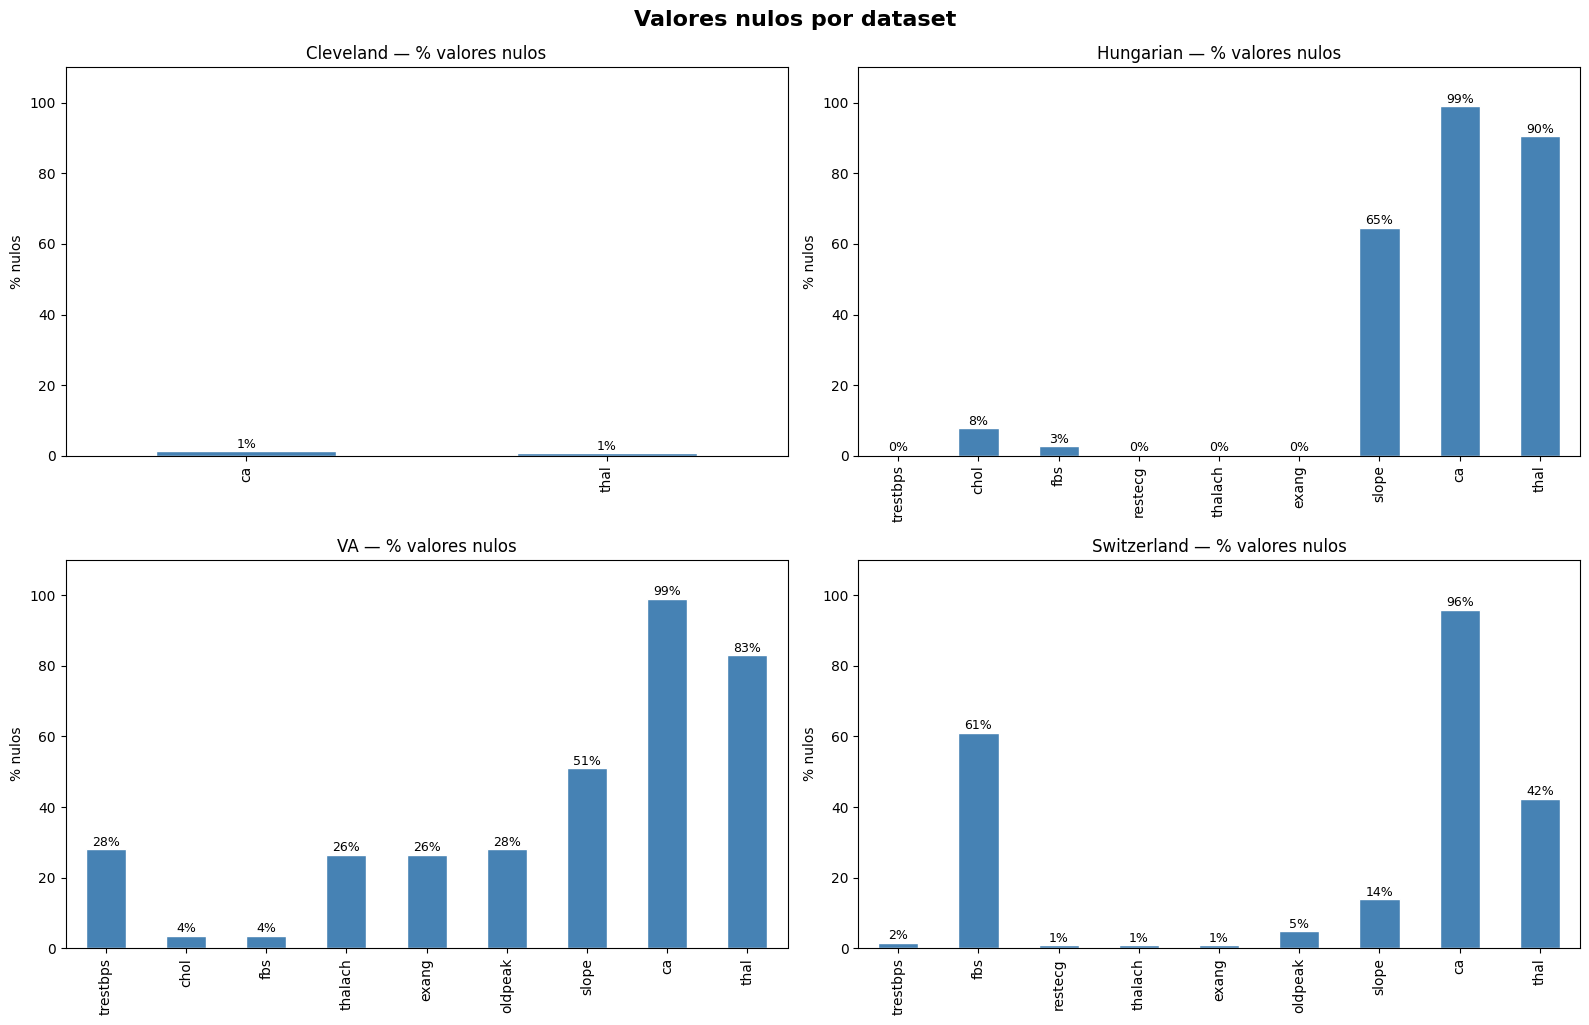

In [7]:
#Análisis de valores nulos

#Se importa matplotlib para crear gráficos y visualizaciones.
import matplotlib.pyplot as plt

#Se crea un diccionario para almacenar todos los datasets.
#La clave representa el nombre del dataset y el valor contiene el DataFrame correspondiente.
datasets = {
    'Cleveland': df_cleveland,
    'Hungarian': df_hungarian,
    'VA': df_va,
    'Switzerland': df_switzerland
}

#Se crea una figura con una cuadrícula de 2 filas y 2 columnas.
#Cada posición contendrá el gráfico de un dataset diferente.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#Se transforma la matriz de ejes en un array plano para facilitar el recorrido con un bucle.
axes = axes.flatten()

#Se recorre cada dataset para analizar sus valores nulos.
for idx, (name, df) in enumerate(datasets.items()):

    #df.isnull() detecta los valores nulos.
    #.mean() calcula el porcentaje de nulos por columna.
    #Se multiplica por 100 para obtener porcentajes.
    missing_pct = df.isnull().mean() * 100

    #Se filtran únicamente las columnas que tienen al menos un valor nulo.
    missing_pct = missing_pct[missing_pct > 0]

    #Si existen columnas con valores nulos:
    if len(missing_pct) > 0:

        #Se genera un gráfico de barras con el porcentaje de nulos.
        missing_pct.plot(
            kind='bar',
            ax=axes[idx],
            color='steelblue',
            edgecolor='white'
        )

        #Título del gráfico.
        axes[idx].set_title(f'{name} — % valores nulos')

        #Etiqueta del eje Y.
        axes[idx].set_ylabel('% nulos')

        #Se establece el límite máximo del eje Y.
        axes[idx].set_ylim(0, 110)

        #Se añade el porcentaje encima de cada barra.
        for p in axes[idx].patches:
            axes[idx].annotate(
                f'{p.get_height():.0f}%',

                #Posición donde se coloca el texto.
                (p.get_x() + p.get_width()/2, p.get_height() + 1),

                #Alineación horizontal.
                ha='center',

                #Tamaño del texto.
                fontsize=9
            )

    #Si el dataset no tiene valores nulos:
    else:

        #Se muestra un mensaje indicando que no existen nulos.
        axes[idx].set_title(f'{name} — Sin valores nulos')

        #Texto centrado dentro del gráfico.
        axes[idx].text(
            0.5,
            0.5,
            'Sin nulos',
            ha='center',
            va='center',
            fontsize=14
        )

#Ajusta automáticamente los espacios entre gráficos.
plt.tight_layout()

#Título general de toda la figura.
plt.suptitle(
    'Valores nulos por dataset',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

#Se guarda la figura en formato PNG.
#bbox_inches='tight' elimina espacios innecesarios alrededor de la imagen.
#dpi=150 mejora la calidad de la imagen exportada.
plt.savefig('fig_nulos.png', bbox_inches='tight', dpi=150)

#Muestra la figura en pantalla.
plt.show()

#Conclusión importante:
#Las columnas slope, ca y thal presentan más del 90% de valores nulos
#en los datasets Hungarian, VA y Switzerland.
#Esto puede afectar negativamente la capacidad de generalización del modelo
#cuando se entrena utilizando datos de múltiples hospitales.

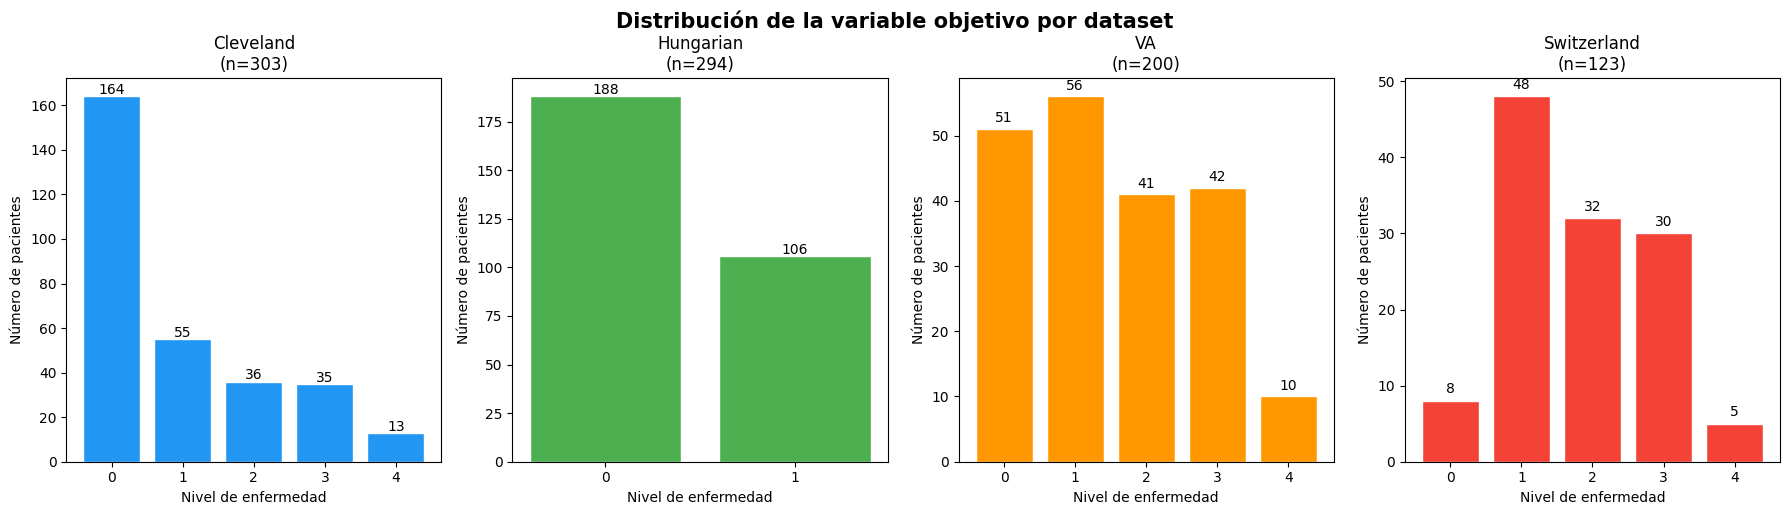

In [8]:
#Distribución de la variable objetivo

#La variable 'num' representa el diagnóstico de enfermedad cardíaca.
#0 indica ausencia de enfermedad.
#Los valores entre 1 y 4 representan distintos niveles de presencia de enfermedad.

#Se crea una figura con 4 gráficos colocados horizontalmente.
#Cada gráfico representará un dataset diferente.
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

#Se define un color diferente para cada dataset.
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

#Se recorre cada dataset para analizar la distribución de la variable objetivo.
for idx, (name, df) in enumerate(datasets.items()):

    #value_counts() cuenta cuántos pacientes hay en cada categoría.
    #sort_index() ordena las categorías de menor a mayor.
    counts = df['num'].value_counts().sort_index()

    #Se crea un gráfico de barras con la distribución de pacientes.
    bars = axes[idx].bar(
        counts.index.astype(str),
        counts.values,
        color=colores[idx],
        edgecolor='white'
    )

    #Título del gráfico.
    #Se incluye también el número total de pacientes del dataset.
    axes[idx].set_title(f'{name}\n(n={len(df)})')

    #Etiqueta del eje X.
    axes[idx].set_xlabel('Nivel de enfermedad')

    #Etiqueta del eje Y.
    axes[idx].set_ylabel('Número de pacientes')

    #Se añade el número exacto encima de cada barra.
    for bar in bars:

        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,

            #Valor mostrado encima de la barra.
            str(int(bar.get_height())),

            #Alineación horizontal del texto.
            ha='center',

            #Tamaño de fuente.
            fontsize=10
        )

#Ajusta automáticamente los espacios entre gráficos.
plt.tight_layout()

#Título general de toda la figura.
plt.suptitle(
    'Distribución de la variable objetivo por dataset',
    y=1.02,
    fontsize=15,
    fontweight='bold'
)

#Se guarda la figura en formato PNG.
#dpi=150 mejora la calidad de la imagen exportada.
plt.savefig('fig_target.png', bbox_inches='tight', dpi=150)

#Muestra los gráficos en pantalla.
plt.show()

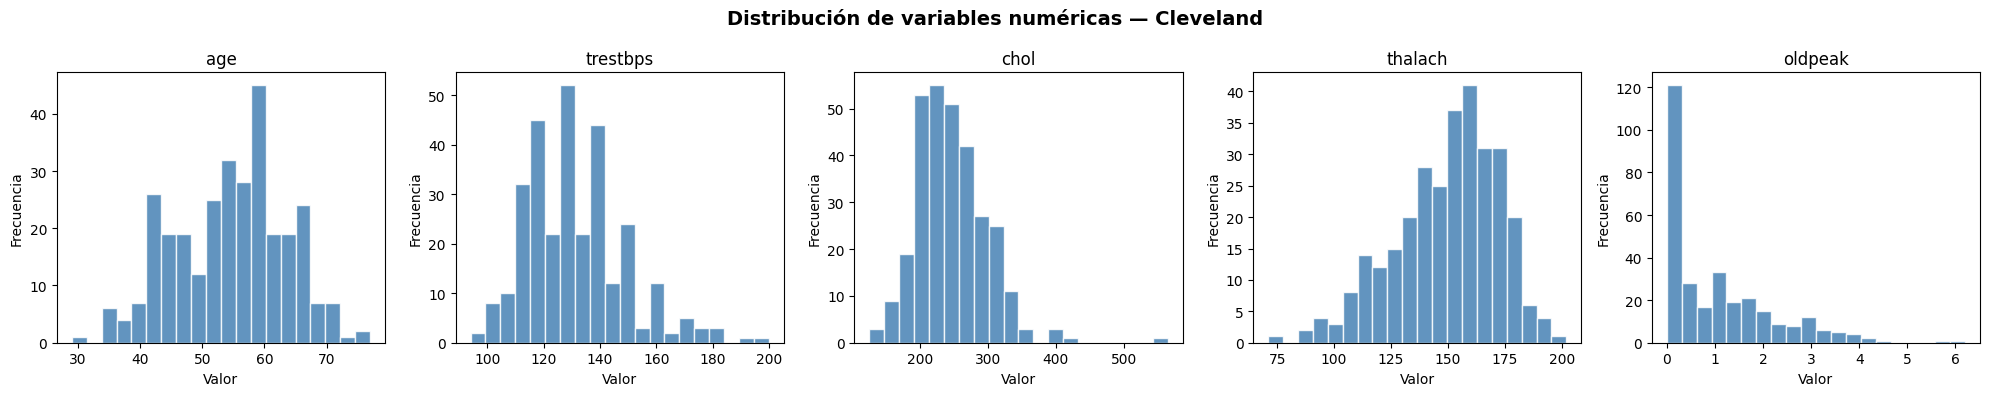

In [9]:
#EDA — distribución de variables numéricas

#EDA (Exploratory Data Analysis):
#Esta sección se utiliza para explorar visualmente cómo se distribuyen
#las variables numéricas del dataset de Cleveland.

#Se seleccionan las variables numéricas que serán analizadas.
num_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#Se crea una figura con 5 gráficos colocados horizontalmente.
#Cada gráfico representará el histograma de una variable distinta.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

#Se recorre cada variable numérica.
for i, col in enumerate(num_vars):

    #Se crea un histograma para visualizar la distribución de valores.
    #dropna() elimina los valores nulos antes de generar el gráfico.
    #bins=20 divide los datos en 20 intervalos.
    axes[i].hist(
        df_cleveland[col].dropna(),
        bins=20,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )

    #Título del gráfico con el nombre de la variable.
    axes[i].set_title(col)

    #Etiqueta del eje X.
    axes[i].set_xlabel('Valor')

    #Etiqueta del eje Y.
    axes[i].set_ylabel('Frecuencia')

#Título general de toda la figura.
plt.suptitle(
    'Distribución de variables numéricas — Cleveland',
    fontsize=14,
    fontweight='bold'
)

#Ajusta automáticamente los espacios entre gráficos.
plt.tight_layout()

#Se guarda la figura en formato PNG.
#dpi=150 mejora la calidad de la imagen exportada.
plt.savefig('fig_histogramas.png', bbox_inches='tight', dpi=150)

#Muestra los gráficos en pantalla.
plt.show()

/tmp/ipykernel_10847/3444841240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10847/3444841240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10847/3444841240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10847/3444841240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10847/3444841240.py:31: FutureWarning

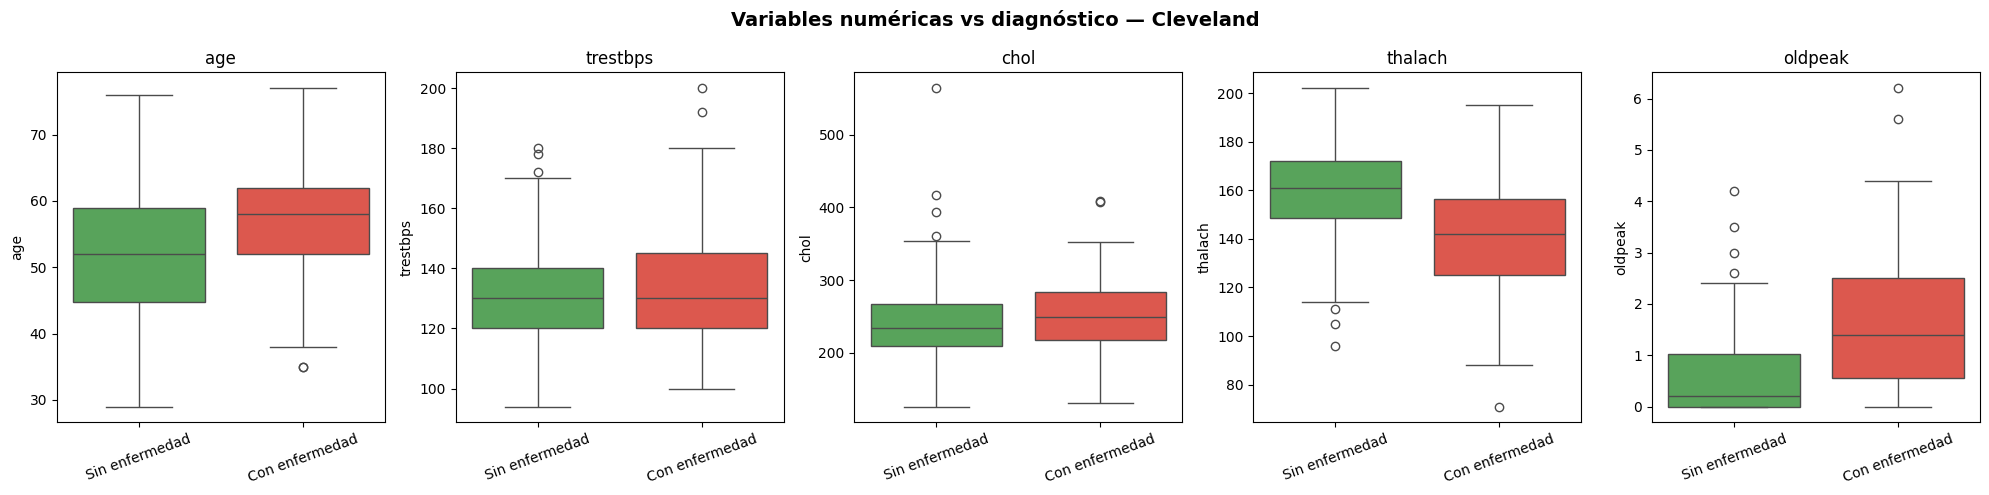

In [10]:
#EDA — boxplots: variables numéricas vs enfermedad

#Se importa Seaborn para crear gráficos estadísticos más avanzados y visualmente más claros.
import seaborn as sns

#Se crea una copia temporal del dataset de Cleveland.
#Esto evita modificar el dataset original durante el análisis visual.
df_eda = df_cleveland.copy()

#La variable 'num' contiene distintos niveles de enfermedad cardíaca.
#Aquí se transforma en un problema binario:
#0 = sin enfermedad
#1 = con enfermedad
df_eda['target'] = (df_eda['num'] > 0).astype(int)

#Se crean etiquetas de texto más fáciles de interpretar en los gráficos.
df_eda['Diagnóstico'] = df_eda['target'].map({
    0: 'Sin enfermedad',
    1: 'Con enfermedad'
})

#Se crea una figura con 5 gráficos colocados horizontalmente.
#Cada gráfico comparará una variable numérica según el diagnóstico.
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

#Se recorren las variables numéricas definidas anteriormente.
for i, col in enumerate(num_vars):

    #Se genera un boxplot para comparar la distribución de cada variable
    #entre pacientes con y sin enfermedad.
    sns.boxplot(
        data=df_eda,
        x='Diagnóstico',
        y=col,
        ax=axes[i],

        #Color verde para pacientes sin enfermedad
        #y rojo para pacientes con enfermedad.
        palette=['#4CAF50', '#F44336']
    )

    #Título del gráfico.
    axes[i].set_title(col)

    #Se elimina la etiqueta del eje X para reducir ruido visual.
    axes[i].set_xlabel('')

    #Se rota ligeramente el texto del eje X para mejorar la legibilidad.
    axes[i].tick_params(axis='x', rotation=20)

#Título general de toda la figura.
plt.suptitle(
    'Variables numéricas vs diagnóstico — Cleveland',
    fontsize=14,
    fontweight='bold'
)

#Ajusta automáticamente los espacios entre gráficos.
plt.tight_layout()

#Se guarda la figura en formato PNG.
#dpi=150 mejora la calidad de la imagen exportada.
plt.savefig('fig_boxplots.png', bbox_inches='tight', dpi=150)

#Muestra los gráficos en pantalla.
plt.show()

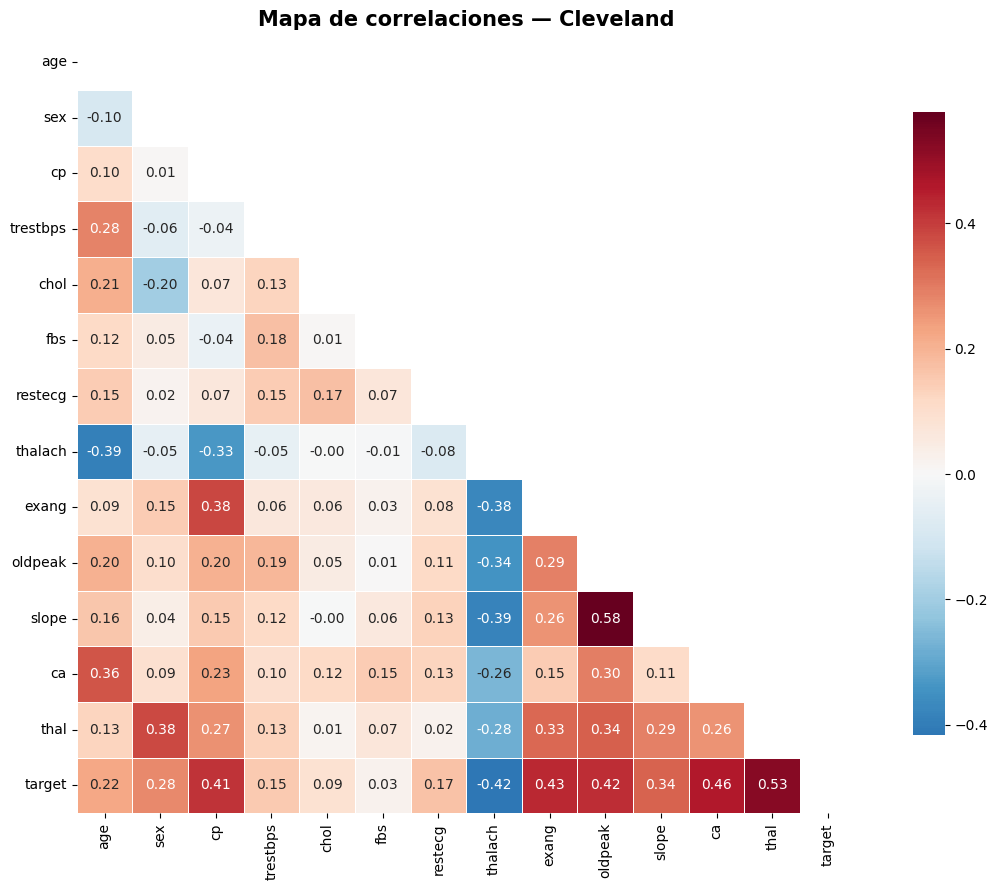

Correlación con el target (valor absoluto):
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264


In [11]:
#EDA — heatmap de correlaciones

#Se importa NumPy para realizar operaciones matemáticas y trabajar con matrices.
import numpy as np

#Se crea una copia temporal del dataset de Cleveland.
#Esto evita modificar el dataset original.
df_corr = df_cleveland.copy()

#Se transforma la variable objetivo en un problema binario:
#0 = sin enfermedad
#1 = con enfermedad
df_corr['target'] = (df_corr['num'] > 0).astype(int)

#Se define el tamaño de la figura.
plt.figure(figsize=(12, 9))

#Se calcula la matriz de correlaciones entre variables.
#La columna 'num' original se elimina porque ya existe la versión binaria 'target'.
corr_matrix = df_corr.drop('num', axis=1).corr()

#Se crea una máscara triangular superior.
#Esto sirve para ocultar la mitad repetida de la matriz y mejorar la visualización.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#Se genera el mapa de calor de correlaciones.
sns.heatmap(

    #Matriz de correlaciones.
    corr_matrix,

    #Aplica la máscara triangular.
    mask=mask,

    #Muestra los valores numéricos dentro de cada celda.
    annot=True,

    #Formato numérico con 2 decimales.
    fmt='.2f',

    #Mapa de colores:
    #Azul = correlación negativa
    #Rojo = correlación positiva
    cmap='RdBu_r',

    #Centro de colores en 0.
    center=0,

    #Hace que las celdas sean cuadradas.
    square=True,

    #Líneas separadoras entre celdas.
    linewidths=0.5,

    #Reduce ligeramente el tamaño de la barra lateral de colores.
    cbar_kws={'shrink': 0.8}
)

#Título general del gráfico.
plt.title(
    'Mapa de correlaciones — Cleveland',
    fontsize=15,
    fontweight='bold'
)

#Ajusta automáticamente los espacios.
plt.tight_layout()

#Se guarda la figura en formato PNG.
#dpi=150 mejora la calidad de la imagen exportada.
plt.savefig('fig_correlacion.png', bbox_inches='tight', dpi=150)

#Muestra el gráfico en pantalla.
plt.show()

#Análisis de correlación con la variable objetivo.

#Se selecciona la correlación de cada variable con 'target'.
#drop('target') elimina la autocorrelación de la propia variable.
#abs() convierte todos los valores en positivos para medir únicamente la fuerza de relación.
#sort_values() ordena las variables de mayor a menor correlación.
corrs_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)

#Se muestra por pantalla el ranking de correlaciones.
print('Correlación con el target (valor absoluto):')
print(corrs_target.to_string())

---
# SECCIÓN 2: Preprocesamiento
### Responsable: Álvaro Falcó

In [12]:
#Preprocesamiento del dataset de Cleveland

#Objetivo del preprocesamiento:
#Preparar los datos para que puedan ser utilizados correctamente
#por los modelos de machine learning.

#Pasos realizados:
#1. Imputar valores nulos utilizando la mediana.
#2. Convertir el target en un problema binario.
#3. Separar variables predictoras (X) y variable objetivo (y).
#4. Normalizar las variables numéricas.
#5. Dividir los datos en entrenamiento y prueba.

#Se importan las herramientas necesarias de scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Se crea una copia del dataset original para evitar modificarlo directamente.
df = df_cleveland.copy()

#1. Binarización del target

#La columna 'num' contiene distintos niveles de enfermedad.
#Se transforma en:
#0 = sin enfermedad
#1 = con enfermedad
df['target'] = (df['num'] > 0).astype(int)

#Se elimina la columna original 'num'
#porque ya no será necesaria.
df = df.drop('num', axis=1)

#2. Separación de variables predictoras y variable objetivo

#X contiene las variables de entrada utilizadas para entrenar el modelo.
X = df.drop('target', axis=1)

#y contiene la variable objetivo que el modelo deberá predecir.
y = df['target']

#3. Imputación de valores nulos

#SimpleImputer permite reemplazar valores faltantes.
#Se utiliza la mediana porque es más robusta frente a valores extremos.
imputer = SimpleImputer(strategy='median')

#fit_transform():
#fit aprende la mediana de cada columna.
#transform reemplaza los valores nulos utilizando esas medianas.
X_imp = imputer.fit_transform(X)

#Se convierte nuevamente el resultado en un DataFrame
#para conservar los nombres de las columnas.
X_imp = pd.DataFrame(X_imp, columns=X.columns)

#4. Normalización de variables

#StandardScaler normaliza los datos utilizando:
#media = 0
#desviación estándar = 1
#Esto ayuda a que muchas técnicas de machine learning funcionen mejor.
scaler = StandardScaler()

#Se ajusta el escalador y se transforman los datos.
X_scaled = scaler.fit_transform(X_imp)

#Se convierte nuevamente en DataFrame para mantener las columnas.
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

#5. División train/test

#Los datos se dividen en:
#80% para entrenamiento
#20% para prueba

#stratify=y mantiene la misma proporción de clases
#en train y test.
#random_state=42 garantiza reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Se muestra el tamaño de los conjuntos resultantes.
print(f'Tamaño train: {X_train.shape} | Tamaño test: {X_test.shape}')

#Se muestra la distribución de clases en train.
print(f'Distribución target en train:\n{y_train.value_counts()}')

#Se muestra la distribución de clases en test.
print(f'Distribución target en test:\n{y_test.value_counts()}')

Tamaño train: (242, 13) | Tamaño test: (61, 13)
Distribución target en train:
target
0    131
1    111
Name: count, dtype: int64
Distribución target en test:
target
0    33
1    28
Name: count, dtype: int64


In [13]:
#Preparación de datos para clasificación multiclase

#Además del problema binario, también se preparan los datos
#para un problema multiclase.

#En este caso:
#0 = sin enfermedad
#1-4 = distintos niveles de enfermedad cardíaca

#Estos datos serán utilizados posteriormente en la Sección 4.

#Se crea una copia del dataset original.
df_multi = df_cleveland.copy()

#X_multi contiene las variables predictoras.
X_multi = df_multi.drop('num', axis=1)

#y_multi contiene la variable objetivo multiclase original.
y_multi = df_multi['num']

#Imputación de valores nulos

#Se reutiliza el mismo imputer previamente ajustado.
#Esto garantiza que los datos se transformen de forma consistente.
#transform() aplica las medianas aprendidas anteriormente.
X_multi_imp = imputer.transform(X_multi)

#Normalización de variables

#Se reutiliza el mismo scaler previamente entrenado.
#Esto asegura que la escala de los datos sea idéntica
#a la utilizada en el problema binario.
X_multi_sc = scaler.transform(X_multi_imp)

#División train/test

#Los datos se dividen en:
#80% entrenamiento
#20% prueba

#stratify=y_multi mantiene la proporción de cada clase
#en ambos conjuntos.
#random_state=42 garantiza reproducibilidad.
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi_sc,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

#Se muestra el tamaño de los conjuntos generados.
print(f'Multiclase — Train: {X_train_m.shape} | Test: {X_test_m.shape}')

Multiclase — Train: (242, 13) | Test: (61, 13)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


---
# SECCIÓN 3: Entrenamiento de Modelos y Evaluación Binaria
### Responsable: Elena Fernandez

Se evalúan tres modelos:
1. **Random Forest**
2. **LDA (Análisis de discriminación lineal)**
3. **SVM (Support Vector Machine)** elegido por su capacidad para separar clases en espacios de alta dimensión con kernel RBF

In [ ]:
#Definición y entrenamiento de los 3 modelos

from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score  #para poder realizar validación cruzada (más fiable que con un único test)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

#instanciamos los modelos con random_state para recorrerlos en bluce sin repetir el código
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LDA':           LinearDiscriminantAnalysis(),
    'SVM (RBF)':     SVC(kernel='rbf', probability=True, random_state=42)
}

#entrenamiento y validación cruzada de 5 pliegues (5-fold, métrica: ROC-AUC)
resultados_cv = {}
for nombre, modelo in models.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc')
    resultados_cv[nombre] = scores
    print(f'{nombre:20s} | CV AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Random Forest        | CV AUC: 0.8846 ± 0.0404
LDA                  | CV AUC: 0.8858 ± 0.0442
SVM (RBF)            | CV AUC: 0.8790 ± 0.0420


In [ ]:
#Evaluación completa en test: métricas por modelo
resultados_test = {}

for nombre, modelo in models.items():
    modelo.fit(X_train, y_train) #entrena el modelo con los datos de entrenamiento
    y_pred = modelo.predict(X_test) #predice si cada paciente del teste tiene o no enfermedad
    y_prob = modelo.predict_proba(X_test)[:, 1] #devuelve la probabilidad

    resultados_test[nombre] = {
        'accuracy': accuracy_score(y_test, y_pred), #porcentaje de aciertos totales
        'auc':      roc_auc_score(y_test, y_prob), #área bajo la curva ROC
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'report':   classification_report(y_test, y_pred, target_names=['Sin enf.', 'Con enf.'])
             #tabla con precision, recall y F1 por cada clase
    }

    print(f'\n {nombre} ')
    print(f'Accuracy: {resultados_test[nombre]["accuracy"]:.4f} | AUC: {resultados_test[nombre]["auc"]:.4f}')
    print(resultados_test[nombre]['report'])


 Random Forest 
Accuracy: 0.9016 | AUC: 0.9513
              precision    recall  f1-score   support

    Sin enf.       0.97      0.85      0.90        33
    Con enf.       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61


 LDA 
Accuracy: 0.8689 | AUC: 0.9405
              precision    recall  f1-score   support

    Sin enf.       0.90      0.85      0.88        33
    Con enf.       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


 SVM (RBF) 
Accuracy: 0.8689 | AUC: 0.9437
              precision    recall  f1-score   support

    Sin enf.       0.90      0.85      0.88        33
    Con enf.       0.83      0.89      0.86        28

    accuracy                           0.87        6

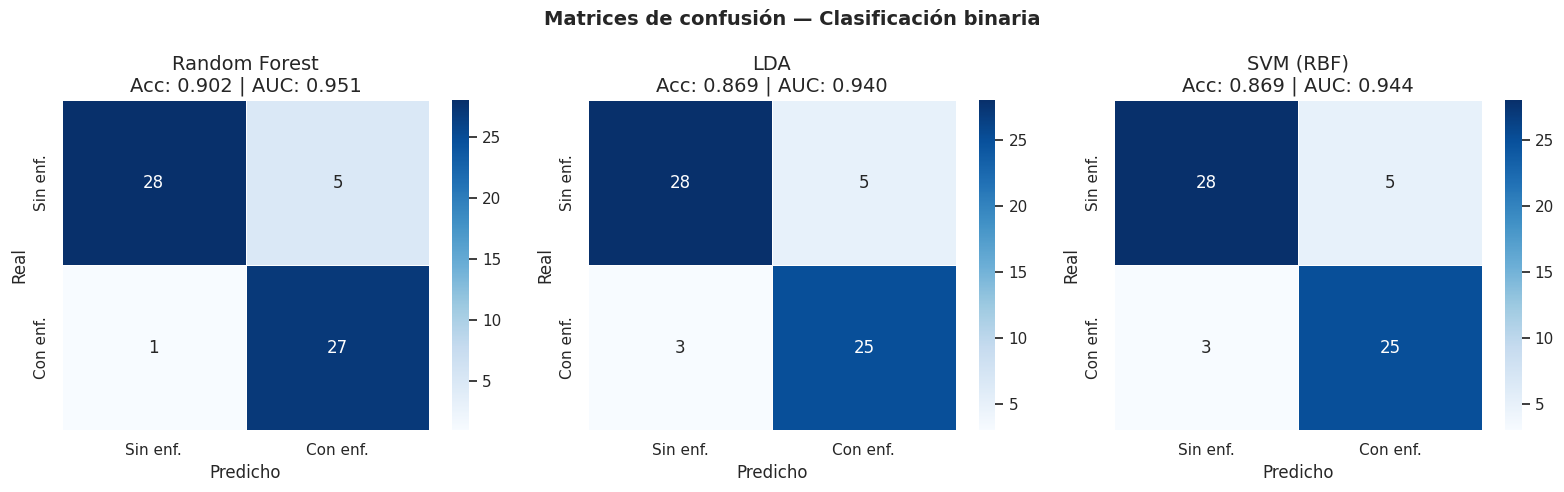

In [ ]:
#Matrices de confusión de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (nombre, res) in enumerate(resultados_test.items()):
    cm = confusion_matrix(y_test, res['y_pred']) #tabla 2x2 que muestra cuántos pacientes el modelo ha clasificado correctamente
    sns.heatmap(cm, annot=True , fmt='d', cmap='Blues', #añade los colores
                #'annot= True' muestra los numeros dentro de cada celda; 'fmt='d'', numero entero.
                xticklabels=['Sin enf.', 'Con enf.'],
                yticklabels=['Sin enf.', 'Con enf.'],
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'{nombre}\nAcc: {res["accuracy"]:.3f} | AUC: {res["auc"]:.3f}')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

plt.suptitle('Matrices de confusión — Clasificación binaria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

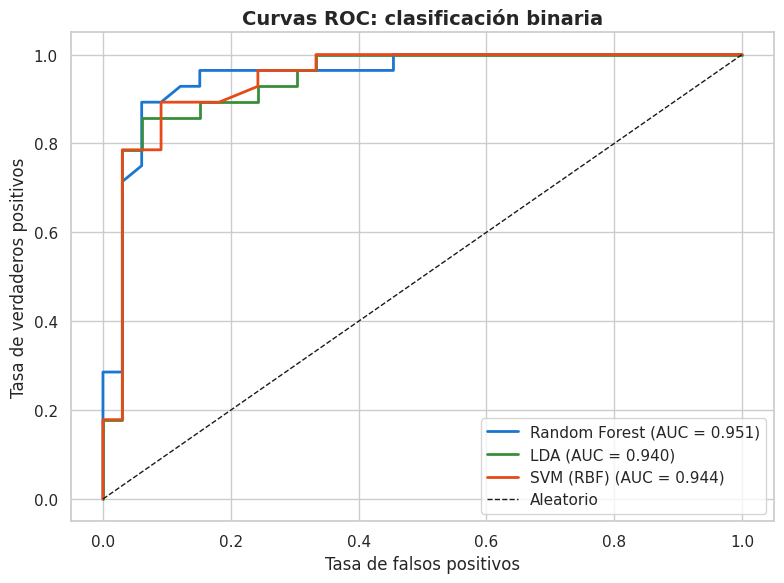

In [ ]:
#Curvas ROC de los 3 modelos
plt.figure(figsize=(8, 6))
colores_roc = ['#1976D2', '#388E3C', '#E64A19']

for (nombre, res), color in zip(resultados_test.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob']) #'roc_curve' calcula los puntos de la linea ROC
    #cuanto más arriba y a la izquierda este la curva mejor es el modelo
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombre} (AUC = {res["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC: clasificación binaria', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc.png', bbox_inches='tight', dpi=150)
plt.show()

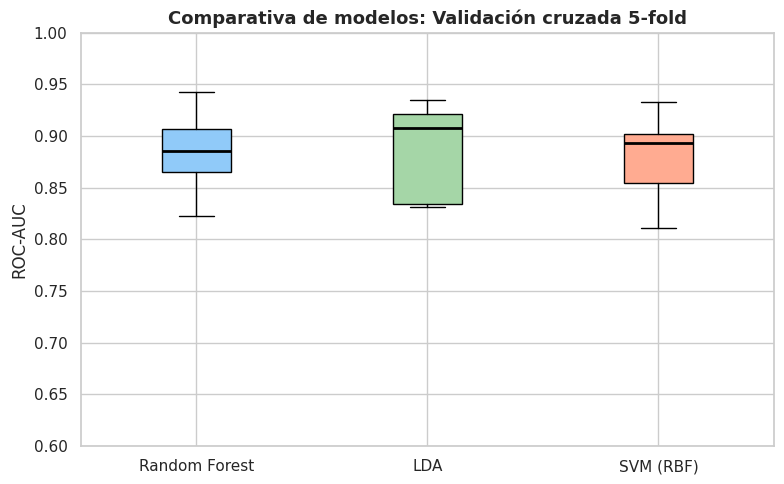


 Mejor modelo seleccionado: Random Forest
   AUC en test: 0.9513


In [ ]:
#Comparativa de validación cruzada de boxplots AUC
fig, ax = plt.subplots(figsize=(8, 5))

data_cv = [scores for scores in resultados_cv.values()]
labels  = list(resultados_cv.keys())

bp = ax.boxplot(data_cv, labels=labels, patch_artist=True, #hace que se grafiquen los 5 sectores de cada modelo como un bloxplot
                medianprops={'color': 'black', 'linewidth': 2})
# con esto se puede ver si el modelo estable o muy variado

colores_box = ['#90CAF9', '#A5D6A7', '#FFAB91']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)

ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.6, 1.0)
ax.set_title('Comparativa de modelos: Validación cruzada 5-fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cv_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

# Selección del mejor modelo
mejor_modelo_nombre = max(resultados_test, key=lambda k: resultados_test[k]['auc'])
mejor_modelo        = models[mejor_modelo_nombre]
print(f'\n Mejor modelo seleccionado: {mejor_modelo_nombre}')
print(f'   AUC en test: {resultados_test[mejor_modelo_nombre]["auc"]:.4f}')

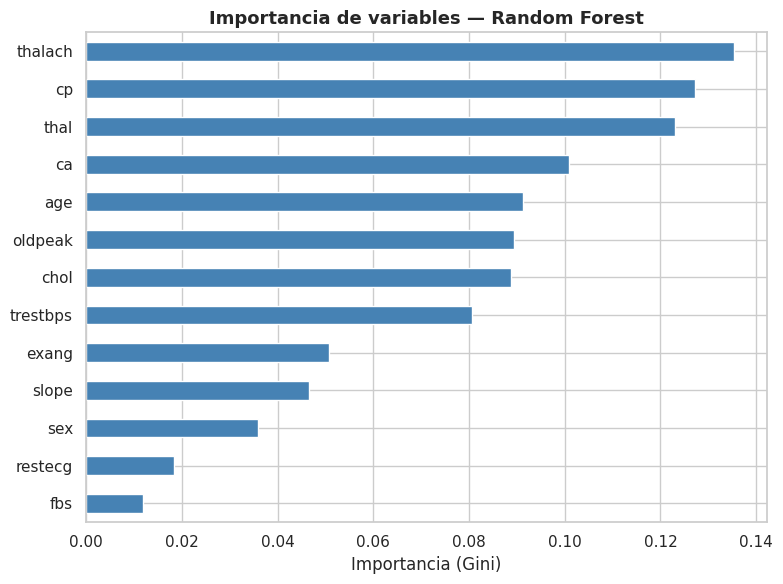

In [ ]:
#Importancia de variables: Random Forest
# en este caso solo disponible para modelos basados en árboles
from sklearn.ensemble import RandomForestClassifier

rf_model = models['Random Forest']
if not hasattr(rf_model, 'feature_importances_'):
    rf_model.fit(X_train, y_train)
# comprueba si el modelo `rf_model` tiene el atributo `feature_importances_`.
#Si no lo tiene, significa que el modelo aún no se ha ajustado y llama a `rf_model.fit(X_train, y_train)` para entrenarlo.

importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importancia de variables — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('fig_importancia.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 4: Clasificación Multiclase (niveles 0-4)
### Responsable: Valery Bedoya

Se evalúa si el mejor modelo puede distinguir entre los **5 niveles de severidad** de la enfermedad, no solo ausencia/presencia.

In [ ]:
#Clasificación multiclase: en lugar de predecir solo si hay enfermedad o no,
#aquí entrenamos el modelo para distinguir entre los 5 niveles de severidad (0-4)
#donde 0 es sin enfermedad y 4 es el caso más grave
from sklearn.metrics import ConfusionMatrixDisplay

#Creamos una nueva instancia de Random Forest para el problema multiclase
#Aunque LDA y SVM también admiten múltiples clases de forma nativa,
#usamos Random Forest porque fue el mejor modelo en la clasificación binaria
mejor_multi = RandomForestClassifier(n_estimators=100, random_state=42)

#Entrenamos con los datos multiclase preparados en la sección de preprocesamiento
mejor_multi.fit(X_train_m, y_train_m)

#Generamos las predicciones sobre el conjunto de test
y_pred_m = mejor_multi.predict(X_test_m)

#Calculamos la accuracy global del modelo multiclase
acc_multi = accuracy_score(y_test_m, y_pred_m)

#Mostramos el resultado global y el reporte detallado por clase
#El reporte incluye precisión, recall y f1 para cada nivel de severidad
#zero_division=0 evita errores cuando algún nivel tiene pocas muestras en test
print('=== Clasificación multiclase (niveles 0-4) ===')
print(f'Accuracy: {acc_multi:.4f}')
print()
print(classification_report(y_test_m, y_pred_m,
                             labels=[0,1,2,3,4],
                             target_names=['Nivel 0','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
                             zero_division=0))

=== Clasificación multiclase (niveles 0-4) ===
Accuracy: 0.5246

              precision    recall  f1-score   support

     Nivel 0       0.78      0.97      0.86        33
     Nivel 1       0.00      0.00      0.00        11
     Nivel 2       0.00      0.00      0.00         7
     Nivel 3       0.00      0.00      0.00         7
     Nivel 4       0.00      0.00      0.00         3

    accuracy                           0.52        61
   macro avg       0.16      0.19      0.17        61
weighted avg       0.42      0.52      0.47        61



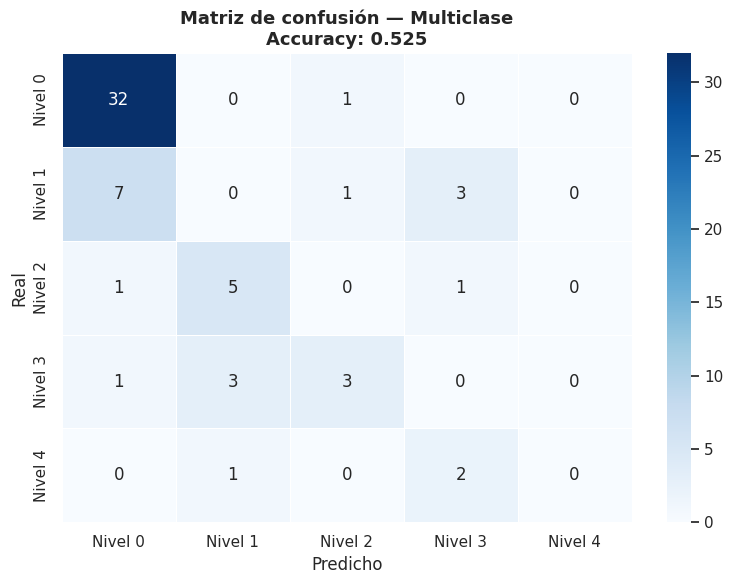


Observación: La clasificación multiclase es más difícil que la binaria.
Los niveles intermedios (2 y 3) son los más difíciles de separar.


In [ ]:
#Calculamos la matriz de confusión para los 5 niveles de severidad
#Cada fila representa el nivel real del paciente y cada columna el nivel predicho
#Los valores en la diagonal principal son las predicciones correctas
cm_multi = confusion_matrix(y_test_m, y_pred_m, labels=[0,1,2,3,4])

#Visualizamos la matriz como un mapa de calor para facilitar su interpretación
#annot=True muestra los valores numéricos dentro de cada celda
#fmt='d' los muestra como enteros, cmap='Blues' usa una escala de azules
plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Nivel {i}' for i in range(5)],
            yticklabels=[f'Nivel {i}' for i in range(5)],
            linewidths=0.5)

#Añadimos título con la accuracy global para tener el resultado visible en el gráfico
plt.title(f'Matriz de confusión — Multiclase\nAccuracy: {acc_multi:.3f}', fontsize=13, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()

#Guardamos la figura en disco para incluirla en el informe
plt.savefig('fig_confusion_multi.png', bbox_inches='tight', dpi=150)
plt.show()

#Conclusión visual: si los errores se concentran fuera de la diagonal en los niveles
#intermedios (2 y 3), confirma que el modelo los confunde entre sí con más frecuencia
#que con los extremos (0 y 4), que tienen características clínicas más diferenciadas
print('\nObservación: La clasificación multiclase es más difícil que la binaria.')
print('Los niveles intermedios (2 y 3) son los más difíciles de separar.')

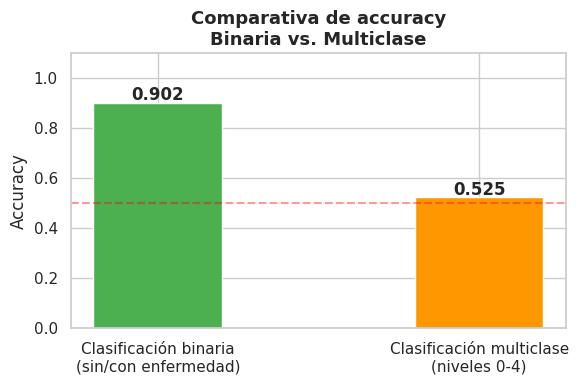

In [ ]:
#Recuperamos la accuracy del mejor modelo en clasificación binaria
#para poder compararla directamente con la obtenida en multiclase
acc_binaria = resultados_test[mejor_modelo_nombre]['accuracy']

#Creamos un gráfico de barras que pone lado a lado ambos resultados
#verde para binaria y naranja para multiclase, para diferenciarlos visualmente
fig, ax = plt.subplots(figsize=(6, 4))
categorias = ['Clasificación binaria\n(sin/con enfermedad)',
              'Clasificación multiclase\n(niveles 0-4)']
valores = [acc_binaria, acc_multi]
bars = ax.bar(categorias, valores, color=['#4CAF50', '#FF9800'], width=0.4, edgecolor='white')

#Añadimos la etiqueta con el valor exacto encima de cada barra
#para que la diferencia entre ambos modelos quede clara de un vistazo
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de accuracy\nBinaria vs. Multiclase', fontsize=13, fontweight='bold')

#Línea de referencia en 0.5: representa un clasificador aleatorio
#cualquier modelo por debajo de esta línea no aporta valor predictivo
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Aleatorio')
plt.tight_layout()

#Guardamos el gráfico para incluirlo en el informe del trabajo
plt.savefig('fig_comparativa_acc.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 5: Generalización a otros hospitales
### Responsable: Valery Bedoya

Se evalúa si el modelo entrenado con datos de Cleveland puede predecir correctamente en datos de hospitales distintos. Las columnas `slope`, `ca` y `thal` tienen >90% de nulos en otros datasets, por lo que se excluyen para garantizar la comparabilidad.

In [ ]:
#Para evaluar el modelo en hospitales externos necesitamos un conjunto de variables
#que esté disponible en los 4 datasets. Las variables slope, ca y thal tienen más
#del 90% de valores nulos en Hungarian, VA y Switzerland, por lo que las excluimos
#y trabajamos solo con las 10 columnas que sí están completas en todos los datasets
COLS_COMUNES = ['age', 'sex', 'cp', 'trestbps', 'chol',
                'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']

def preparar_dataset_externo(df):
    """Preprocesa un dataset externo usando las columnas comunes.
    Binariza el target, imputa nulos y aplica el scaler de Cleveland."""
    d = df.copy()

    #Convertimos el target a binario: 0 sin enfermedad, 1 con enfermedad
    d['target'] = (d['num'] > 0).astype(int)
    X_ext = d[COLS_COMUNES]
    y_ext = d['target']

    #Cada hospital puede tener sus propios nulos en las columnas comunes,
    #los imputamos con la mediana de ese dataset en concreto
    imp_ext = SimpleImputer(strategy='median')
    X_ext_imp = imp_ext.fit_transform(X_ext)

    #Devolvemos los datos sin escalar porque el escalado se aplica fuera
    #usando el scaler entrenado con Cleveland, para mantener consistencia
    return X_ext_imp, y_ext

#Reentrenamos el modelo usando solo las 10 columnas comunes sobre Cleveland
#así el modelo y los datasets externos comparten exactamente el mismo espacio de variables
X_cleveland_com = df_cleveland[COLS_COMUNES]
y_cleveland_bin = (df_cleveland['num'] > 0).astype(int)

#Creamos un imputer y un scaler nuevos, entrenados exclusivamente
#con las columnas comunes de Cleveland, independientes de los de secciones anteriores
imp_com    = SimpleImputer(strategy='median')
scaler_com = StandardScaler()

X_clev_imp = imp_com.fit_transform(X_cleveland_com)
X_clev_sc  = scaler_com.fit_transform(X_clev_imp)

#División estratificada train/test con los mismos parámetros que en secciones anteriores
#para que los resultados sean comparables
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clev_sc, y_cleveland_bin, test_size=0.2, random_state=42, stratify=y_cleveland_bin
)

#Entrenamos Random Forest con las 10 columnas comunes
#este será el modelo que aplicaremos directamente sobre los datasets externos
rf_com = RandomForestClassifier(n_estimators=100, random_state=42)
rf_com.fit(X_tr_c, y_tr_c)

#Comprobamos la accuracy en el test de Cleveland como punto de referencia
#antes de evaluar en hospitales externos
acc_clev_com = accuracy_score(y_te_c, rf_com.predict(X_te_c))
print(f'Accuracy Cleveland (cols. comunes): {acc_clev_com:.4f}')

Accuracy Cleveland (cols. comunes): 0.9016


In [ ]:
#Definimos los tres datasets externos sobre los que vamos a evaluar el modelo
#ninguno de estos datos fue visto por el modelo durante el entrenamiento
datasets_ext = {
    'Hungarian':   df_hungarian,
    'VA':          df_va,
    'Switzerland': df_switzerland
}

#Inicializamos el diccionario de resultados con la accuracy de Cleveland como referencia
#así podemos comparar directamente la degradación al cambiar de hospital
resultados_ext = {'Cleveland (test)': acc_clev_com}

#Iteramos sobre cada hospital externo aplicando siempre el mismo modelo
for nombre, df_ext in datasets_ext.items():

    #Preprocesamos el dataset externo con la función definida anteriormente:
    #binariza el target e imputa nulos con la mediana propia de ese dataset
    X_ext_imp, y_ext = preparar_dataset_externo(df_ext)

    #Aplicamos el scaler de Cleveland para que los datos externos queden
    #en el mismo espacio numérico que los datos con los que se entrenó el modelo
    X_ext_sc = scaler_com.transform(X_ext_imp)

    #Generamos predicciones y calculamos la accuracy para este hospital
    y_pred_ext = rf_com.predict(X_ext_sc)
    acc_ext    = accuracy_score(y_ext, y_pred_ext)

    #Guardamos el resultado para usarlo en la visualización posterior
    resultados_ext[nombre] = acc_ext

    #Mostramos el reporte completo por clase para ver si el modelo falla
    #más en detectar enfermos o en detectar sanos en cada hospital
    print(f'\n=== {nombre} ===')
    print(f'Accuracy: {acc_ext:.4f}')
    print(classification_report(y_ext, y_pred_ext,
                                 target_names=['Sin enf.', 'Con enf.'],
                                 zero_division=0))


=== Hungarian ===
Accuracy: 0.7891
              precision    recall  f1-score   support

    Sin enf.       0.83      0.85      0.84       188
    Con enf.       0.72      0.69      0.70       106

    accuracy                           0.79       294
   macro avg       0.77      0.77      0.77       294
weighted avg       0.79      0.79      0.79       294


=== VA ===
Accuracy: 0.7150
              precision    recall  f1-score   support

    Sin enf.       0.45      0.55      0.50        51
    Con enf.       0.83      0.77      0.80       149

    accuracy                           0.71       200
   macro avg       0.64      0.66      0.65       200
weighted avg       0.74      0.71      0.72       200


=== Switzerland ===
Accuracy: 0.4797
              precision    recall  f1-score   support

    Sin enf.       0.09      0.75      0.16         8
    Con enf.       0.96      0.46      0.62       115

    accuracy                           0.48       123
   macro avg       0.53  

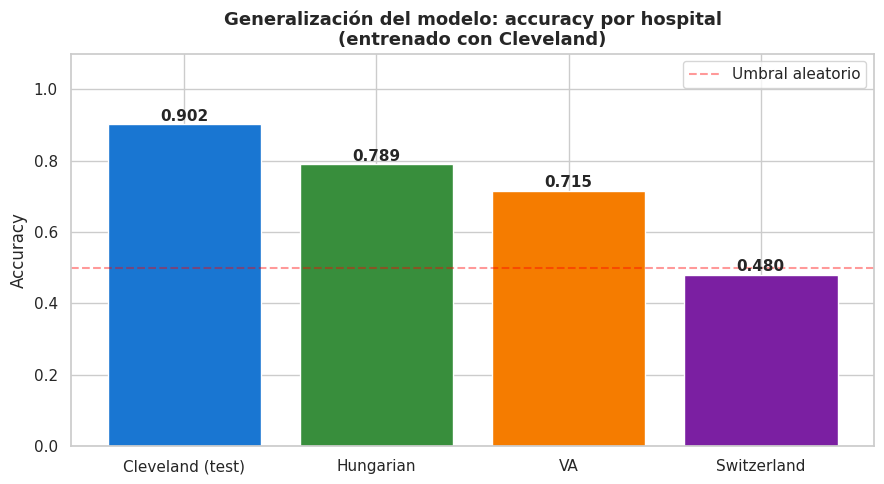

In [ ]:
#Creamos un gráfico de barras para visualizar de un vistazo cómo varía
#la accuracy del modelo según el hospital, usando un color distinto por dataset
#para facilitar la comparación visual
fig, ax = plt.subplots(figsize=(9, 5))
nombres   = list(resultados_ext.keys())
accs      = list(resultados_ext.values())
colores_h = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

bars = ax.bar(nombres, accs, color=colores_h, edgecolor='white')

#Añadimos el valor exacto de accuracy encima de cada barra
#para no tener que leer el eje y y poder comparar los números directamente
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Generalización del modelo: accuracy por hospital\n(entrenado con Cleveland)', fontsize=13, fontweight='bold')

#La línea roja en 0.5 marca el umbral de un clasificador aleatorio
#cualquier barra por debajo indicaría que el modelo no generaliza en ese hospital
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Umbral aleatorio')
ax.legend()
plt.tight_layout()

#Guardamos la figura para incluirla en el informe del trabajo
plt.savefig('fig_generalizacion.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 6: Discusión de resultados y Conclusiones
### Responsable: Valery Bedoya

### Resumen de resultados


In [ ]:
#Imprimimos un resumen consolidado con todos los resultados del trabajo
#dividido en tres bloques: clasificación binaria, multiclase y generalización

#Bloque 1: comparativa de los tres modelos en la tarea binaria sobre Cleveland
#mostramos accuracy y AUC para poder identificar rápidamente el mejor modelo
print('=' * 60)
print('Tabla resumen — clasificación binaria (Cleveland test)')
print('=' * 60)
for nombre, res in resultados_test.items():
    print(f'{nombre:20s} | Accuracy: {res["accuracy"]:.4f} | AUC: {res["auc"]:.4f}')

print()

#Bloque 2: resultado del mejor modelo en la tarea multiclase
#un único número de accuracy ya que el reporte detallado se mostró en la sección anterior
print('=' * 60)
print(f'Clasificación multiclase (0-4) — Accuracy: {acc_multi:.4f}')
print('=' * 60)

print()

#Bloque 3: capacidad de generalización del modelo a otros hospitales
#la primera fila es Cleveland como referencia, las siguientes son los externos
print('=' * 60)
print('Generalización multi-hospital (Random Forest, cols. comunes)')
print('=' * 60)
for nombre, acc in resultados_ext.items():
    print(f'{nombre:25s} | Accuracy: {acc:.4f}')

Tabla resumen — clasificación binaria (Cleveland test)
Random Forest        | Accuracy: 0.9016 | AUC: 0.9513
LDA                  | Accuracy: 0.8689 | AUC: 0.9405
SVM (RBF)            | Accuracy: 0.8689 | AUC: 0.9437

Clasificación multiclase (0-4) — Accuracy: 0.5246

Generalización multi-hospital (Random Forest, cols. comunes)
Cleveland (test)          | Accuracy: 0.9016
Hungarian                 | Accuracy: 0.7891
VA                        | Accuracy: 0.7150
Switzerland               | Accuracy: 0.4797
